# Requisito 2 - Combinatorial-UCB con budget, versione base

Piu' campagne, ambiente stocastico congiunto, vincolo di budget e conflict graph. L'algoritmo estende alla versione combinatoria l'approccio UCB-like del requisito 1: per ogni arm atomico (campagna, bid) stimo reward e costo medi, uso UCB sul reward e LCB sul costo, e a ogni round un LP sceglie una distribuzione sulle super-azioni con costo medio al piu' rho = B/T.

## Modello

A ogni round scelgo un bid per campagna (una super-azione). Per la campagna i vinco se il bid supera il massimo bid concorrente m_i, ottengo v_i - b_i e pago b_i. Il conflict graph vieta bid positivi simultanei su campagne in conflitto.

I massimi bid concorrenti hanno marginali Beta diverse per campagna. Per rendere la distribuzione davvero congiunta, in una frazione dei round tutte le campagne condividono lo stesso quantile: le marginali restano le stesse ma i mercati si muovono insieme (round "caldi" e "freddi" comuni).

In [51]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, stats

SEED = 17
T = 3000
TRIALS = 20
B = 700.0
RHO = B / T

BID_GRID = np.linspace(0.0, 1.0, 11)
VALUES = np.array([0.95, 0.85, 0.78, 0.90])
CONFLICT_EDGES = [(0, 1), (1, 2), (2, 3)]
N_CAMPAIGNS = len(VALUES)

# marginali Beta del massimo bid concorrente, una per campagna
BETA_PARAMS = [(2.0, 5.0), (2.8, 3.8), (3.5, 3.0), (2.3, 4.0)]
# probabilita' che in un round tutte le campagne condividano lo stesso quantile
CORR_P = 0.3

np.set_printoptions(precision=3, suppress=True)
EPS = 1e-12

In [52]:
# arm atomici: coppie (campagna, bid) con 0 < bid <= v_i
ARM_CAMPAIGN, ARM_BID = [], []
for i in range(N_CAMPAIGNS):
    for b in BID_GRID:
        if 0.0 < b <= VALUES[i]:
            ARM_CAMPAIGN.append(i)
            ARM_BID.append(b)
ARM_CAMPAIGN = np.array(ARM_CAMPAIGN)
ARM_BID = np.array(ARM_BID)
N_ARMS = len(ARM_BID)
ARM_MAX_REWARD = VALUES[ARM_CAMPAIGN] - ARM_BID   # reward massimo dell'arm: vinta l'asta vale v - b

# super-azioni: un bid per campagna, nessuna coppia in conflitto attiva insieme
grids = [np.concatenate([[0.0], np.unique(ARM_BID[ARM_CAMPAIGN == i])]) for i in range(N_CAMPAIGNS)]
superactions = []
for bids in itertools.product(*grids):
    bids = np.array(bids)
    if any(bids[i] > 0 and bids[j] > 0 for i, j in CONFLICT_EDGES):
        continue
    superactions.append(bids)
SA_BIDS = np.array(superactions)
SA_BID_SUMS = SA_BIDS.sum(axis=1)
K = len(SA_BIDS)
NULL_IDX = 0
assert np.all(SA_BIDS[NULL_IDX] == 0)
MAX_SA_BID = float(SA_BID_SUMS.max())

# matrice di appartenenza super-azione -> arm atomici
SA_ARMS = np.zeros((K, N_ARMS))
for k in range(K):
    for a in range(N_ARMS):
        if SA_BIDS[k, ARM_CAMPAIGN[a]] == ARM_BID[a]:
            SA_ARMS[k, a] = 1.0

# medie vere degli arm dalla CDF Beta (le marginali non cambiano con la correlazione)
ARM_WIN_PROB = np.array([stats.beta.cdf(ARM_BID[a], *BETA_PARAMS[ARM_CAMPAIGN[a]]) for a in range(N_ARMS)])
TRUE_R = ARM_MAX_REWARD * ARM_WIN_PROB
TRUE_C = ARM_BID * ARM_WIN_PROB
SA_TRUE_R = SA_ARMS @ TRUE_R
SA_TRUE_C = SA_ARMS @ TRUE_C

print(f'arm atomici: {N_ARMS}, super-azioni ammissibili: {K}, costo massimo per round: {MAX_SA_BID:.2f}')

arm atomici: 33, super-azioni ammissibili: 250, costo massimo per round: 1.80


## Ambiente

correlazione empirica tra campagne:
[[1.   0.3  0.31 0.3 ]
 [0.3  1.   0.3  0.31]
 [0.31 0.3  1.   0.32]
 [0.3  0.31 0.32 1.  ]]


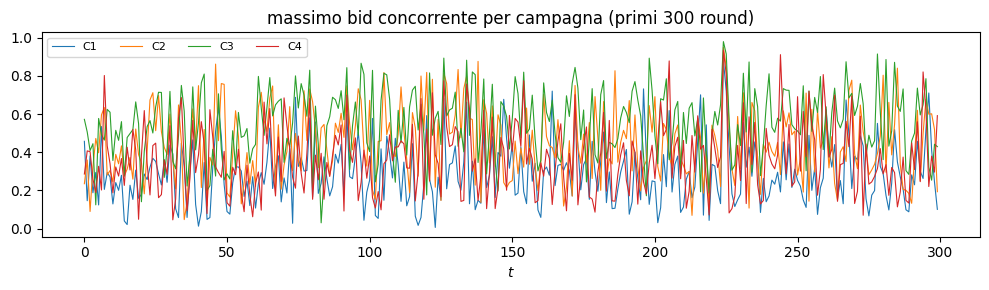

In [53]:
def build_thresholds(horizon, seed):
    # joint distribution: marginali Beta con un fattore comune.
    # In una frazione CORR_P dei round tutte le campagne usano lo stesso quantile u,
    # negli altri i quantili sono indipendenti. Le marginali restano Beta(a_i, b_i).
    rng = np.random.default_rng(seed)
    u = rng.uniform(size=(horizon, N_CAMPAIGNS))
    common = rng.uniform(size=horizon)
    shared = rng.uniform(size=horizon) < CORR_P
    u[shared] = common[shared, None]
    M = np.zeros_like(u)
    for i, (a, b) in enumerate(BETA_PARAMS):
        M[:, i] = stats.beta.ppf(u[:, i], a, b)
    return M


class MultiCampaignEnv:
    # una first-price auction per campagna per round, feedback semi-bandit
    def __init__(self, horizon, seed):
        self.M = build_thresholds(horizon, seed)
        self.t = 0

    def round(self, bids):
        m = self.M[self.t]
        self.t += 1
        wins = (bids >= m).astype(float)
        utilities = (VALUES - bids) * wins
        costs = bids * wins
        return wins, utilities, costs


Mst = build_thresholds(T, SEED)
fig, ax = plt.subplots(figsize=(10, 3))
for i in range(N_CAMPAIGNS):
    ax.plot(Mst[:300, i], lw=0.8, label=f'C{i+1}')
ax.set_title('massimo bid concorrente per campagna (primi 300 round)')
ax.set_xlabel('$t$'); ax.legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

corr = np.corrcoef(Mst.T)
print('correlazione empirica tra campagne:')
print(np.round(corr, 2))

## Clairvoyant

Il benchmark conosce le medie vere di reward e costo e risolve l'LP sulle super-azioni con vincolo rho = B/T. Il regret e' contro il suo reward atteso per round.

In [54]:
def solve_lp(scores, costs, rho, feasible=None):
    # LP sul simplesso delle super-azioni con vincolo di costo medio <= rho
    if feasible is None:
        feasible = np.ones(K, dtype=bool)
    bounds = [(0.0, 1.0) if feasible[k] else (0.0, 0.0) for k in range(K)]
    res = optimize.linprog(-scores, A_ub=[costs], b_ub=[max(rho, 0.0)],
                           A_eq=[np.ones(K)], b_eq=[1.0], bounds=bounds, method='highs')
    if (not res.success) or res.x is None:
        gamma = np.zeros(K); gamma[NULL_IDX] = 1.0
        return gamma
    gamma = np.clip(res.x, 0.0, None)
    if gamma.sum() <= 0:
        gamma = np.zeros(K); gamma[NULL_IDX] = 1.0
        return gamma
    return gamma / gamma.sum()


oracle_gamma = solve_lp(SA_TRUE_R, SA_TRUE_C, RHO)
ORACLE_REWARD = float(oracle_gamma @ SA_TRUE_R)
ORACLE_COST = float(oracle_gamma @ SA_TRUE_C)
print(f'oracle: reward atteso per round {ORACLE_REWARD:.4f}, costo atteso {ORACLE_COST:.4f}, rho = {RHO:.4f}')

oracle: reward atteso per round 0.5478, costo atteso 0.2333, rho = 0.2333


## Agenti

Oltre al Combinatorial-UCB, due riferimenti: random tra le super-azioni pagabili (limite inferiore) e la policy del clairvoyant (limite superiore raggiungibile rispettando il vincolo in media).

In [55]:
class RandomAgent:
    # baseline: super-azione uniforme tra quelle pagabili
    def __init__(self, budget, horizon, rng):
        self.budget = budget
        self.rng = rng
        self.k_t = NULL_IDX

    def act(self):
        affordable = np.flatnonzero(SA_BID_SUMS <= self.budget + EPS)
        self.k_t = NULL_IDX if affordable.size == 0 else int(self.rng.choice(affordable))
        return SA_BIDS[self.k_t]

    def update(self, wins, utilities, costs):
        self.budget = max(0.0, self.budget - costs.sum())


class ClairvoyantPolicy:
    # gioca la distribuzione dell'oracle (medie vere), serve da riferimento superiore
    def __init__(self, budget, horizon, rng):
        self.budget = budget
        self.rng = rng
        self.k_t = NULL_IDX

    def act(self):
        if self.budget < MAX_SA_BID:
            self.k_t = NULL_IDX
        else:
            self.k_t = int(self.rng.choice(K, p=oracle_gamma))
        return SA_BIDS[self.k_t]

    def update(self, wins, utilities, costs):
        self.budget = max(0.0, self.budget - costs.sum())


class CombUCBAgent:
    # Combinatorial-UCB con budget: medie empiriche per arm, reward UCB e costo LCB,
    # LP con rho = B/T fisso. I range dei bonus sono v-b per il reward e b per il costo.
    def __init__(self, budget, horizon, rng):
        self.budget = budget
        self.horizon = horizon
        self.rng = rng
        self.avg_f = np.zeros(N_ARMS)
        self.avg_c = np.zeros(N_ARMS)
        self.N_pulls = np.zeros(N_ARMS)
        self.k_t = NULL_IDX

    def act(self):
        if self.budget < MAX_SA_BID:      # stop quando anche il round peggiore non e' coperto
            self.k_t = NULL_IDX
            return SA_BIDS[NULL_IDX]
        bonus_f = ARM_MAX_REWARD * np.sqrt(2 * np.log(self.horizon) / np.maximum(self.N_pulls, 1))
        bonus_c = ARM_BID * np.sqrt(2 * np.log(self.horizon) / np.maximum(self.N_pulls, 1))
        f_ucb = self.avg_f + bonus_f
        c_lcb = np.maximum(self.avg_c - bonus_c, 0.0)
        never = self.N_pulls == 0
        f_ucb[never] = ARM_MAX_REWARD[never]   # arm mai giocato: reward al massimo, costo a zero
        c_lcb[never] = 0.0
        gamma = solve_lp(SA_ARMS @ f_ucb, SA_ARMS @ c_lcb, RHO)
        self.k_t = int(self.rng.choice(K, p=gamma))
        return SA_BIDS[self.k_t]

    def update(self, wins, utilities, costs):
        played = np.flatnonzero(SA_ARMS[self.k_t])
        for a in played:
            self.N_pulls[a] += 1
            i = ARM_CAMPAIGN[a]
            self.avg_f[a] += (utilities[i] - self.avg_f[a]) / self.N_pulls[a]
            self.avg_c[a] += (costs[i] - self.avg_c[a]) / self.N_pulls[a]
        self.budget = max(0.0, self.budget - costs.sum())

## Simulazione

20 trial appaiati: a parita' di seed tutti gli agenti vedono la stessa sequenza di mercato. Metrica principale: pseudo-regret contro il reward atteso dell'oracle; riporto anche il regret realizzato e la spesa.

In [56]:
def run_trial(agent_cls, seed):
    env = MultiCampaignEnv(T, seed)
    agent = agent_cls(B, T, np.random.default_rng(seed + 1_000))
    exp_rewards = np.zeros(T)
    rewards = np.zeros(T)
    costs = np.zeros(T)
    selected = np.zeros(T, dtype=int)
    for t in range(T):
        bids = agent.act()
        wins, utilities, cost_vec = env.round(bids)
        agent.update(wins, utilities, cost_vec)
        exp_rewards[t] = SA_TRUE_R[agent.k_t]
        rewards[t] = utilities.sum()
        costs[t] = cost_vec.sum()
        selected[t] = agent.k_t
    return {'agent': agent,
            'pseudo_regret': np.cumsum(ORACLE_REWARD - exp_rewards),
            'realized_regret': np.cumsum(ORACLE_REWARD - rewards),
            'cum_cost': np.cumsum(costs),
            'reward_total': rewards.sum(),
            'selected': selected}


def mean_sem(curves):
    m = np.vstack(curves)
    return m.mean(axis=0), m.std(axis=0, ddof=1) / np.sqrt(m.shape[0])


def summarize(name, runs):
    pseudo = np.vstack([r['pseudo_regret'] for r in runs])
    realized = np.vstack([r['realized_regret'] for r in runs])
    spend = np.array([r['cum_cost'][-1] for r in runs])
    cps = [T // 4 - 1, T // 2 - 1, 3 * T // 4 - 1, T - 1]
    mp = pseudo.mean(axis=0)
    return {'agent': name,
            'reward_totale': float(np.mean([r['reward_total'] for r in runs])),
            'pct_oracle': 100 * float(np.mean([r['reward_total'] for r in runs])) / (ORACLE_REWARD * T),
            'spesa': float(spend.mean()),
            'pseudo_regret_finale': float(mp[-1]),
            'realized_regret_finale': float(realized.mean(axis=0)[-1]),
            'pseudo_Rt_su_t': [round(float(mp[c] / (c + 1)), 4) for c in cps]}

In [57]:
random_runs, clair_runs, ucb_runs = [], [], []
for i in range(TRIALS):
    random_runs.append(run_trial(RandomAgent, 100 + i))
    clair_runs.append(run_trial(ClairvoyantPolicy, 100 + i))
    ucb_runs.append(run_trial(CombUCBAgent, 100 + i))

summary = pd.DataFrame([summarize('Random', random_runs),
                        summarize('Clairvoyant policy', clair_runs),
                        summarize('Combinatorial-UCB', ucb_runs)])
summary

,agent,reward_totale,pct_oracle,spesa,pseudo_regret_finale,realized_regret_finale,pseudo_Rt_su_t
0,Random,341.0075,20.748400,700.000,1305.557836,1302.528872,"[0.2159, 0.3225, 0.3976, 0.4352]"
1,Clairvoyant policy,1628.9350,99.111588,693.450,11.802113,14.601372,"[0.0, 0.0001, -0.0, 0.0039]"
2,Combinatorial-UCB,1047.2180,63.717361,698.575,595.154806,596.318372,"[0.0385, -0.0033, 0.0819, 0.1984]"


## Grafici

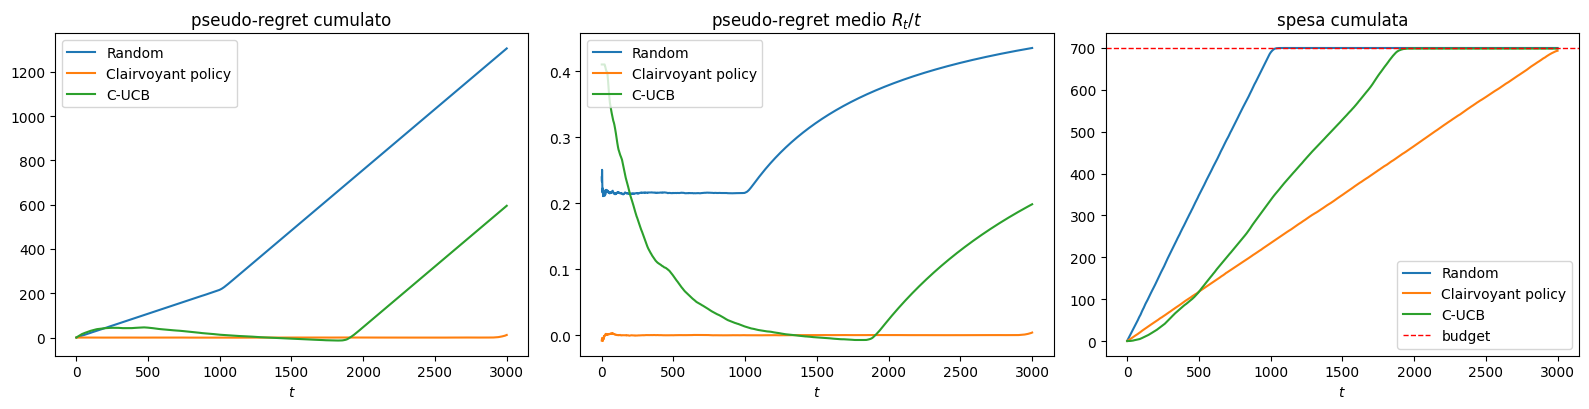

In [58]:
x = np.arange(1, T + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for name, runs in [('Random', random_runs), ('Clairvoyant policy', clair_runs), ('C-UCB', ucb_runs)]:
    m, sem = mean_sem([r['pseudo_regret'] for r in runs])
    axes[0].plot(x, m, label=name)
    axes[0].fill_between(x, m - sem, m + sem, alpha=0.2)
    axes[1].plot(x, m / x, label=name)
    mc, _ = mean_sem([r['cum_cost'] for r in runs])
    axes[2].plot(x, mc, label=name)
axes[0].set_title('pseudo-regret cumulato'); axes[0].set_xlabel('$t$'); axes[0].legend()
axes[1].set_title('pseudo-regret medio $R_t/t$'); axes[1].set_xlabel('$t$'); axes[1].legend()
axes[2].axhline(B, color='red', ls='--', lw=1, label='budget')
axes[2].set_title('spesa cumulata'); axes[2].set_xlabel('$t$'); axes[2].legend()
plt.tight_layout(); plt.show()

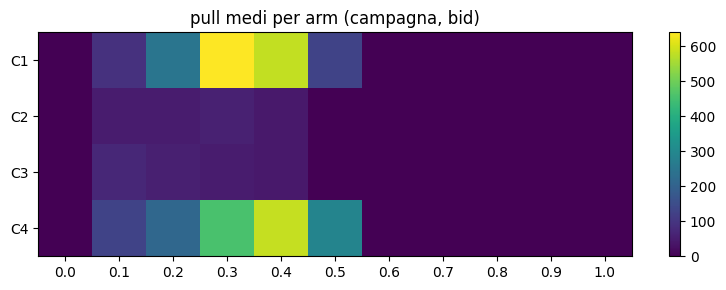

In [59]:
# numero medio di pull per arm (media sui trial)
pulls = np.zeros((N_CAMPAIGNS, len(BID_GRID)))
counts = np.zeros_like(pulls)
attr = 'N_pulls' if hasattr(ucb_runs[0]['agent'], 'N_pulls') else 'n_obs'
for r in ucb_runs:
    ag = r['agent']
    n = getattr(ag, attr)
    for a in range(N_ARMS):
        j = int(round(ARM_BID[a] * 10))
        pulls[ARM_CAMPAIGN[a], j] += n[a] / TRIALS

fig, ax = plt.subplots(figsize=(8, 3))
im = ax.imshow(pulls, aspect='auto')
ax.set_xticks(range(len(BID_GRID))); ax.set_xticklabels([f'{b:.1f}' for b in BID_GRID])
ax.set_yticks(range(N_CAMPAIGNS)); ax.set_yticklabels([f'C{i+1}' for i in range(N_CAMPAIGNS)])
ax.set_title('pull medi per arm (campagna, bid)')
fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

In [60]:
spends = np.array([r['cum_cost'][-1] for r in ucb_runs])
print(f'spesa massima sui trial: {spends.max():.1f} (budget {B:.0f})')

spesa massima sui trial: 699.0 (budget 700)


## Lettura del risultato

Il Combinatorial-UCB impara bene le medie: a meta' orizzonte il pseudo-regret medio e' quasi nullo (checkpoint ~-0.003 a T/2), molto vicino alla clairvoyant policy. Il problema e' il pacing: il costo LCB sottostima sistematicamente i costi veri, quindi l'LP crede di rispettare rho mentre spende di piu'. Il budget si esaurisce prima della fine dell'orizzonte, da li' in poi l'agente gioca la super-azione nulla e il regret riparte lineare: il pseudo-regret medio finale risale a ~0.198 (contro 0.435 del random).

Il vincolo e' comunque rispettato in ogni trial (spesa massima 699 su 700). Il limite della baseline quindi non sta nell'apprendimento ma nella coppia costo LCB + rho fisso: e' il punto da cui parte la versione migliorata.